# Fashion Product Adoption Experiments

## 1. Research Question

How do influencer position and social influence strength affect the adoption of a new fashion product within a consumer social network?



## 2. Model Design and Parameters


### 2.1 Model Overview

The model represents the diffusion of a new fashion product through a consumer social network. Each node represents a consumer and each edge represents a social connection between two consumers.

At the beginning of the simulation, one consumer is selected as the influencer and is treated as the initial adopter of the product. Other consumers may subsequently purchase the product based on their individual baseline purchase probability and the purchasing behaviour of their neighbours.

At each simulation step, the purchase probability of consumer \($i$\) is calculated as:


$P_i(t)$ = $\min$(1, $p_i$ + $\alpha$ $F_i(t)$)


where:

- \($p_i$\) is the individual baseline purchase probability of consumer \($i$\);
- \($\alpha$\) is the social influence strength; and
- \($F_i(t)$\) is the fraction of consumer \($i$\)'s neighbours who have purchased the product at time \($t$\).

The simulation continues until all consumers have purchased the product or the maximum number of simulation steps is reached.

During each simulation step, purchase decisions are evaluated for all consumers who have not yet purchased the product. All decisions are based on the network state at the beginning of the step, and new purchases are applied after all consumers have been evaluated. This synchronous update prevents the processing order of consumers from affecting adoption within the same simulation step.

### 2.2 Network Model

A Barabási–Albert preferential attachment network is used to represent the consumer social network. Each node represents a consumer, while each edge represents a social connection through which social influence may occur.

The Barabási–Albert model was selected because it produces heterogeneous node degrees, including a small number of highly connected nodes. This property is useful for this study because the research question investigates whether the position of an influencer within the network affects product adoption.

#### Comparison of Candidate Network Models
| Network | Basic idea | Fit for our project |
|---|---|---|
| Erdős–Rényi random | Connections form randomly with similar opportunity | Usable, but less natural for studying influential hubs |
| Watts–Strogatz small-world | Strong local connections + some long-distance links | Interesting for social communities |
| **Barabási–Albert** | Some nodes become highly connected hubs | **Selected: provides heterogeneous node degrees suitable for comparing influencer positions** |

The network is defined by two parameters: \($n$\), the total number of consumers, and \($m$\), the number of edges created by each new node when it joins the network. In the current model, \($n$=100\) and \($m$=3\).

### 2.3 Influencer Position

Two influencer-position strategies are considered:

- **Central influencer:** the consumer with the highest degree in the network.
- **Less-central influencer:** a consumer located approximately at the median of the degree ranking.
  - The median-degree position is used to represent a less-central consumer with a more typical level of connectivity, rather than selecting a node from the minimum-degree group.

Degree represents the number of direct social connections a consumer has. The central strategy therefore places the influencer at a highly connected node, while the less-central strategy represents an influencer with fewer direct connections.

### 2.4 Customer Purchase Behaviour

Each consumer is assigned an individual baseline purchase probability \($p_i$\) during initialisation. The baseline probability represents the consumer's tendency to purchase the product independently of social influence. In the current model, \($p_i$\) is independently sampled from a uniform distribution between 0.01 and 0.10.

The baseline probability is assigned once at the beginning of a simulation and remains unchanged throughout that simulation.

During each simulation step, consumers who have not yet purchased the product may adopt it. Their purchase probability increases according to the proportion of their neighbours who have already purchased the product. Once a consumer purchases the product, the purchase is irreversible.

### 2.5 Social Influence Strength

Social influence strength, \($\alpha$\), controls how strongly the purchasing behaviour of neighbouring consumers affects a consumer's purchase probability.

A larger value of \($\alpha$\) means that consumers are more responsive to neighbours who have already purchased the product.

For example, if 40% of a consumer's neighbours have purchased the product:

\[
$F_i(t)$ = 0.4
\]

with \($\alpha$ = 0.5\), the contribution from social influence is:

\[
0.5 $\times$ 0.4 = 0.2
\]

This value is added to the consumer's individual baseline purchase probability.

### 2.6 Model Parameters

| Parameter | Symbol/code | Current value | Role |
|---|---|---:|---|
| Number of consumers | $N$ | 100 | Fixed parameter |
| Edges per new node | \$m$ | 3 | Fixed parameter |
| Baseline probability | $p_i$ | $U$(0.01,0.10) | Customer attribute |
| Influencer position | `influencer_strategy` | central / less-central | **Independent variable** |
| Social influence | $\alpha$ | TBD | **Independent variable** |
| Simulation horizon | $T$ | 28 days | Fixed parameter |
| Final adoption rate | — | Measured | **Dependent variable** |
| Adoption speed | — | Measured | **Dependent variable** |

- Simulation time: Each simulation step represents one day. The simulation is conducted over a fixed 28-day (four-week) observation period, representing a short-term marketing campaign. A fixed campaign duration allows adoption outcomes to be compared consistently across experimental conditions. Short-term marketing campaigns may operate over approximately 2–4 weeks, providing a practical basis for the selected observation period [Ref:https://impremis.com/blogs/how-long-should-a-marketing-campaign-last]

### 2.7 Model Assumptions

- The consumer network contains 100 consumers throughout the experiments. The network size is fixed so that the effects of influencer position and social influence strength can be compared under the same network size.
- The Barabási–Albert network uses \($m$=3\), meaning that each new node forms three connections when it is added to the network. This value is fixed throughout the main experiments to control network connectivity.
  - We are not claiming 100 and 3 represent the real world exactly. We hold them constant because they are not the variables being investigated, and we later check whether our conclusions depend heavily on these choices.
- At \($t$=0\), only the selected influencer has purchased.
- All other customers start with purchased = False.
- Each ordinary customer has an individual baseline purchase probability, assigned once at initialization.
- That baseline stays fixed during one simulation run.
- Customers can later purchase either because of their baseline tendency or because neighbours have purchased.
- Purchase is irreversible: once a consumer purchases the product, they remain an adopter for the remainder of the simulation.
- All purchase decisions within a simulation step are based on the network state at the beginning of that step.
- The social network remains fixed throughout each simulation.

## 3. Baseline Simulation

Before conducting the main experiments, a baseline simulation is performed to verify that the model behaves as expected.

The baseline simulation uses the fixed network parameters defined in Section 2 and one initial combination of influencer position and social influence strength. The adoption process is then examined over time to confirm that product adoption spreads through the network as intended.

### 3.1 Initialise Baseline Simulation

The baseline simulation uses 100 consumers and a Barabási–Albert attachment parameter of \(m=3\). A central influencer is selected as the initial adopter.

A social influence strength of \(\alpha=0.5\) is used initially to inspect the behaviour of the model. This value is used only for the baseline model check and does not represent the final experimental conditions.

In [36]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.model import (
    create_network,
    select_influencer,
    initialise_customers,
    purchase_probability,
    simulation_step,
    run_simulation
)

In [37]:
# Baseline model parameters
NUM_CUSTOMERS = 100
EDGES_PER_NEW_NODE = 3
INFLUENCER_STRATEGY = "central"
SOCIAL_INFLUENCE = 0
MAX_STEPS = 28

In [38]:
G_no_influence, history_no_influence = run_simulation(
    num_customers=NUM_CUSTOMERS,
    edges_per_new_node=EDGES_PER_NEW_NODE,
    influencer_strategy="central",
    social_influence=0.0,
    max_steps=MAX_STEPS
)

print("Adoption history:", history_no_influence)
print(
    "Final adopters:",
    history_no_influence[-1]
)
print(
    "Final adoption rate:",
    f"{history_no_influence[-1] / NUM_CUSTOMERS * 100:.1f}%"
)


Adoption history: [1, 5, 11, 15, 18, 22, 28, 36, 37, 42, 44, 44, 46, 49, 50, 51, 51, 54, 54, 55, 56, 59, 61, 61, 62, 62, 62, 63, 66]
Final adopters: 66
Final adoption rate: 66.0%


### 3.2 Inspect Network Structure

In [39]:
G = create_network(
    NUM_CUSTOMERS,
    EDGES_PER_NEW_NODE
)

degrees = dict(G.degree())

print("Number of customers:", G.number_of_nodes())
print("Number of connections:", G.number_of_edges())
print("Minimum degree:", min(degrees.values()))
print("Maximum degree:", max(degrees.values()))
print(
    "Average degree:",
    sum(degrees.values()) / len(degrees)
)

Number of customers: 100
Number of connections: 291
Minimum degree: 3
Maximum degree: 34
Average degree: 5.82


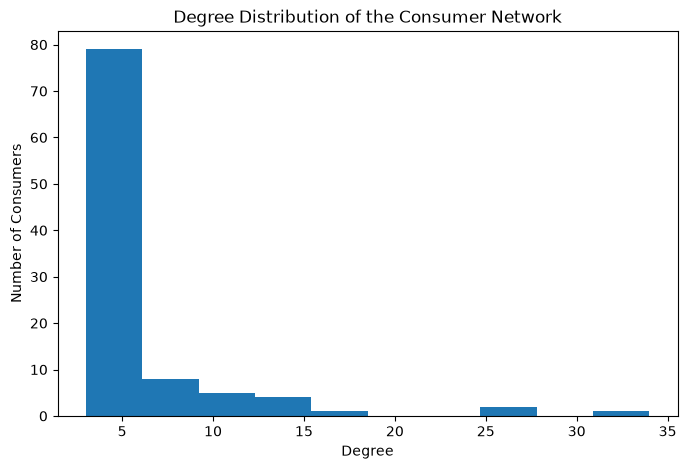

In [40]:
plt.figure(figsize=(8, 5))

plt.hist(degrees.values())

plt.xlabel("Degree")
plt.ylabel("Number of Consumers")
plt.title("Degree Distribution of the Consumer Network")

plt.show()

### 3.3 Inspect Influencer Position

In [41]:
central_influencer = select_influencer(
    G,
    "central"
)

less_central_influencer = select_influencer(
    G,
    "less_central"
)

print(
    "Central influencer:",
    central_influencer,
    "Degree:",
    G.degree(central_influencer)
)

print(
    "Less-central influencer:",
    less_central_influencer,
    "Degree:",
    G.degree(less_central_influencer)
)

Central influencer: 0 Degree: 34
Less-central influencer: 62 Degree: 4


In [42]:
from collections import Counter

degree_counts = Counter(degrees.values())

for degree in sorted(degree_counts):
    print(
        f"Degree {degree}: "
        f"{degree_counts[degree]} customers"
    )

Degree 3: 33 customers
Degree 4: 29 customers
Degree 5: 6 customers
Degree 6: 11 customers
Degree 7: 7 customers
Degree 8: 1 customers
Degree 10: 4 customers
Degree 12: 1 customers
Degree 13: 1 customers
Degree 14: 1 customers
Degree 15: 2 customers
Degree 18: 1 customers
Degree 26: 1 customers
Degree 27: 1 customers
Degree 34: 1 customers


### 3.4 Visualise the Network Graph

#### 3.4.1 Central strategy

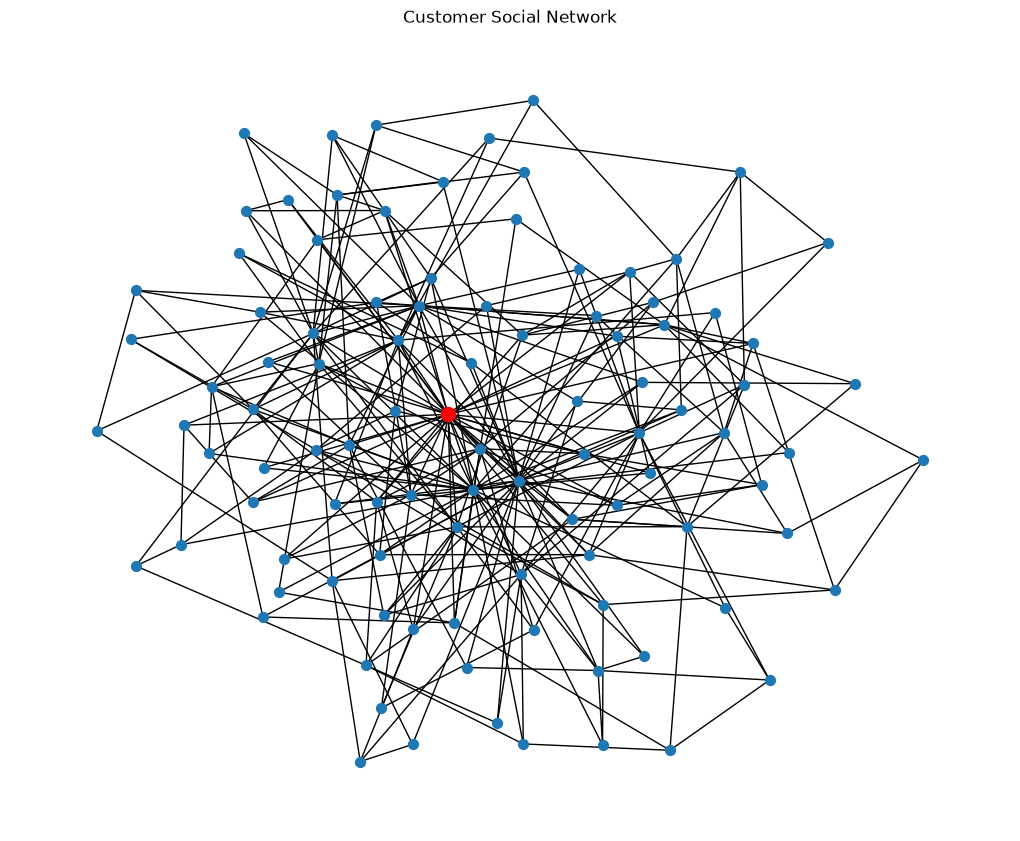

In [43]:
# Calculate positions once
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10, 8))

# Draw the whole network
nx.draw(
    G,
    pos,
    node_size=50,
    with_labels=False
)

# Highlight highest-degree customer
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=[central_influencer],
    node_size=100,
    node_color="red"
)

plt.title("Customer Social Network")
plt.show()

#### 3.4.2 Less-central strategy

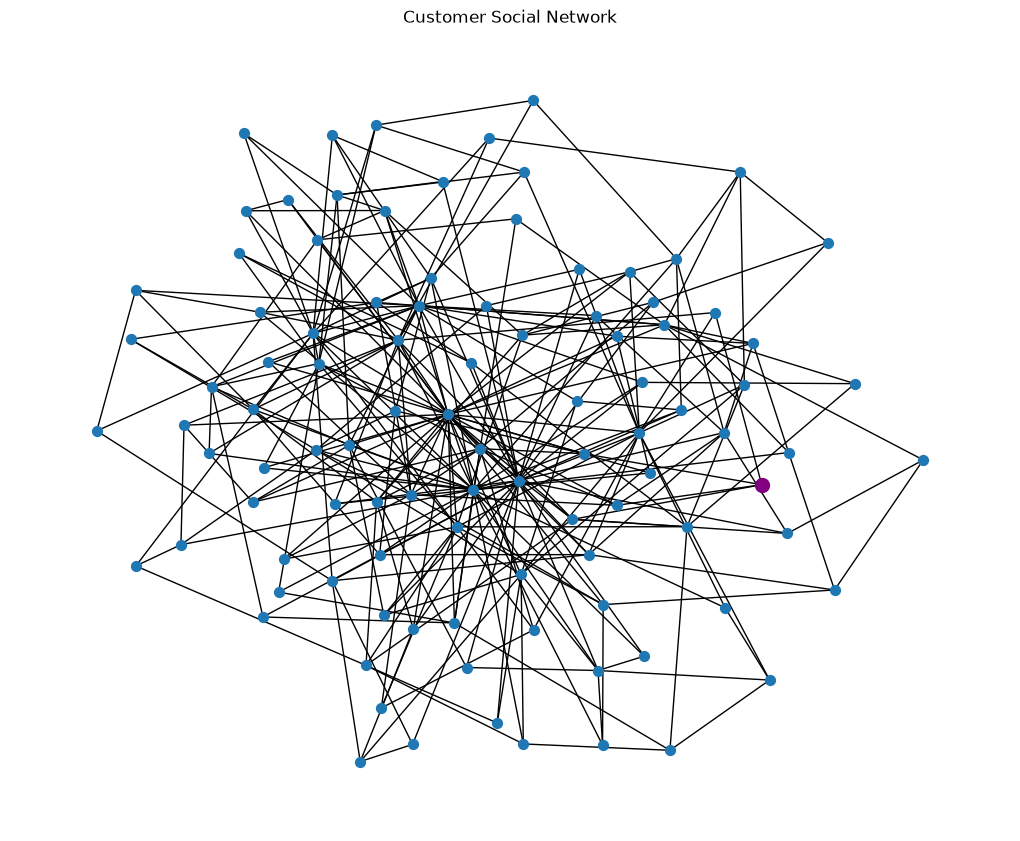

In [44]:
# Calculate positions once
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10, 8))

# Draw the whole network
nx.draw(
    G,
    pos,
    node_size=50,
    with_labels=False
)

# Highlight highest-degree customer
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=[less_central_influencer],
    node_size=100,
    node_color="purple"
)

plt.title("Customer Social Network")
plt.show()

### 3.4 Run Baseline Simulation


In [45]:
G_baseline, adoption_history = run_simulation(
    num_customers=NUM_CUSTOMERS,
    edges_per_new_node=EDGES_PER_NEW_NODE,
    influencer_strategy=INFLUENCER_STRATEGY,
    social_influence=SOCIAL_INFLUENCE,
    max_steps=MAX_STEPS
)

print("Adoption history:", adoption_history)
print("Number of simulation steps:", len(adoption_history) - 1)
print("Final number of adopters:", adoption_history[-1])

Adoption history: [1, 5, 12, 19, 22, 28, 33, 37, 40, 43, 43, 49, 50, 58, 59, 62, 63, 65, 65, 69, 70, 72, 72, 74, 74, 75, 77, 78, 78]
Number of simulation steps: 28
Final number of adopters: 78


In [46]:
final_adoption_rate = (
    adoption_history[-1] / NUM_CUSTOMERS
) * 100

print(
    f"Final adoption rate: "
    f"{final_adoption_rate:.1f}%"
)

Final adoption rate: 78.0%


### 3.5 Visualise Adoption Over Time

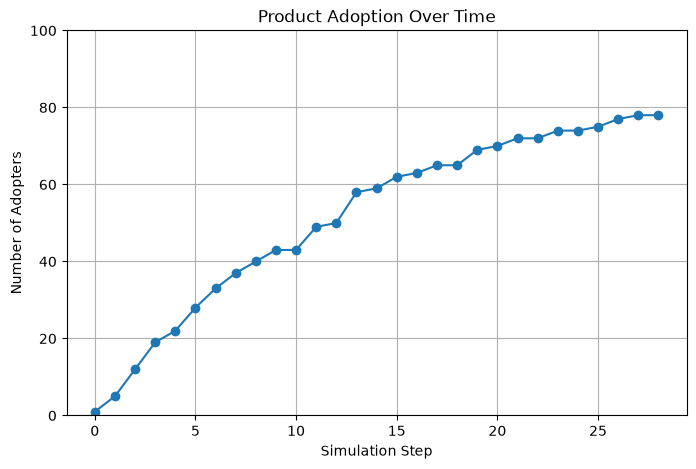

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(len(adoption_history)),
    adoption_history,
    marker="o"
)

plt.xlabel("Simulation Step")
plt.ylabel("Number of Adopters")
plt.title("Product Adoption Over Time")

plt.ylim(0, NUM_CUSTOMERS)
plt.grid(True)

plt.show()

### 3.6 Baseline Observation

The baseline simulation began with one initial adopter and reached 100 adopters after 14 simulation steps. The number of adopters increased monotonically throughout the simulation, which is consistent with the model assumption that product adoption is irreversible.

The simulation therefore demonstrates that the implemented model can generate diffusion of product adoption through the consumer network. However, this baseline run represents only one stochastic simulation and is not sufficient for drawing conclusions about the effects of influencer position or social influence strength. Repeated simulations and controlled comparisons are required in the main experiments.

### 3.7 Social Influence Parameter Check

Before conducting the main experiments, several values of the social influence parameter are tested to examine whether the selected range produces distinguishable adoption behaviour.

#### Finer diagnostic
0.0–0.2 → useful variation mainly toward lower α values

In [48]:
social_influence_values = [
    0.00,
    0.025,
    0.05,
    0.075,
    0.10,
    0.125,
    0.15,
    0.175,
    0.20
]

for alpha in social_influence_values:

    G_test, history_test = run_simulation(
        num_customers=NUM_CUSTOMERS,
        edges_per_new_node=EDGES_PER_NEW_NODE,
        influencer_strategy="central",
        social_influence=alpha,
        max_steps=MAX_STEPS
    )

    final_adopters = history_test[-1]

    final_rate = (
        final_adopters / NUM_CUSTOMERS
    ) * 100

    print(
        f"alpha = {alpha:.3f} | "
        f"final adopters = {final_adopters} | "
        f"adoption rate = {final_rate:.2f}%"
    )

alpha = 0.000 | final adopters = 76 | adoption rate = 76.00%
alpha = 0.025 | final adopters = 79 | adoption rate = 79.00%
alpha = 0.050 | final adopters = 84 | adoption rate = 84.00%
alpha = 0.075 | final adopters = 86 | adoption rate = 86.00%
alpha = 0.100 | final adopters = 94 | adoption rate = 94.00%
alpha = 0.125 | final adopters = 100 | adoption rate = 100.00%
alpha = 0.150 | final adopters = 99 | adoption rate = 99.00%
alpha = 0.175 | final adopters = 98 | adoption rate = 98.00%
alpha = 0.200 | final adopters = 100 | adoption rate = 100.00%


#### Repeated simulations
verify the pattern isn't just randomness

In [49]:
G1, history1 = run_simulation(
    num_customers=100,
    edges_per_new_node=3,
    influencer_strategy="central",
    social_influence=0.1,
    max_steps=28,
    seed=42
)

G2, history2 = run_simulation(
    num_customers=100,
    edges_per_new_node=3,
    influencer_strategy="central",
    social_influence=0.1,
    max_steps=28,
    seed=42
)

print("Run 1:", history1)
print("Run 2:", history2)

print("Same result:", history1 == history2)

Run 1: [1, 3, 11, 17, 22, 28, 36, 41, 44, 49, 56, 62, 67, 68, 71, 76, 78, 81, 82, 85, 86, 86, 88, 89, 92, 92, 93, 94, 94]
Run 2: [1, 3, 11, 17, 22, 28, 36, 41, 44, 49, 56, 62, 67, 68, 71, 76, 78, 81, 82, 85, 86, 86, 88, 89, 92, 92, 93, 94, 94]
Same result: True


In [50]:
G3, history3 = run_simulation(
    num_customers=100,
    edges_per_new_node=3,
    influencer_strategy="central",
    social_influence=0.1,
    max_steps=28,
    seed=43
)

print("Seed 42:", history1)
print("Seed 43:", history3)

print("Same result:", history1 == history3)

Seed 42: [1, 3, 11, 17, 22, 28, 36, 41, 44, 49, 56, 62, 67, 68, 71, 76, 78, 81, 82, 85, 86, 86, 88, 89, 92, 92, 93, 94, 94]
Seed 43: [1, 3, 8, 14, 20, 26, 33, 38, 48, 52, 60, 66, 68, 69, 74, 77, 81, 85, 88, 89, 89, 90, 93, 94, 94, 97, 97, 97, 98]
Same result: False


### 3.8 Adoption Speed
Adoption speed = the first day on which at least 50% of consumers have purchased the product.

In [51]:
def calculate_adoption_speed(
    adoption_history,
    num_customers
):
    target = num_customers * 0.5

    for day, adopters in enumerate(adoption_history):
        if adopters >= target:
            return day

    return None

In [52]:
speed = calculate_adoption_speed(
    history1,
    100
)

print("Time to 50% adoption:", speed, "days")

Time to 50% adoption: 10 days


#### Test of repeated-simulation function

In [53]:
def run_repeated_simulations(
    num_runs,
    num_customers,
    edges_per_new_node,
    influencer_strategy,
    social_influence,
    max_steps
):
    final_adoption_rates = []
    adoption_speeds = []

    for run in range(num_runs):

        seed = run

        G, adoption_history = run_simulation(
            num_customers=num_customers,
            edges_per_new_node=edges_per_new_node,
            influencer_strategy=influencer_strategy,
            social_influence=social_influence,
            max_steps=max_steps,
            seed=seed
        )

        # Final adoption rate
        final_adoption_rate = (
            adoption_history[-1]
            / num_customers
        ) * 100

        final_adoption_rates.append(
            final_adoption_rate
        )

        # Adoption speed
        adoption_speed = calculate_adoption_speed(
            adoption_history,
            num_customers
        )

        adoption_speeds.append(
            adoption_speed
        )

    return final_adoption_rates, adoption_speeds

In [54]:
test_rates, test_speeds = run_repeated_simulations(
    num_runs=10,
    num_customers=100,
    edges_per_new_node=3,
    influencer_strategy="central",
    social_influence=0.05,
    max_steps=28
)

print("Final adoption rates:")
print(test_rates)

print("Adoption speeds:")
print(test_speeds)

Final adoption rates:
[91.0, 91.0, 92.0, 85.0, 87.0, 85.0, 88.0, 88.0, 81.0, 89.0]
Adoption speeds:
[9, 11, 10, 11, 9, 10, 9, 13, 14, 10]


### 3.9 Compare candidate $\alpha$ values

In [55]:
import statistics

In [56]:
alpha_values = [
    0.00,
    0.025,
    0.05,
    0.075,
    0.10,
    0.125,
    0.15
]

for alpha in alpha_values:

    rates, speeds = run_repeated_simulations(
        num_runs=30,
        num_customers=100,
        edges_per_new_node=3,
        influencer_strategy="central",
        social_influence=alpha,
        max_steps=28
    )

    mean_rate = statistics.mean(rates)

    # Remove None before calculating mean speed
    reached_speeds = [
        speed for speed in speeds
        if speed is not None
    ]

    if reached_speeds:
        mean_speed = statistics.mean(
            reached_speeds
        )
    else:
        mean_speed = None

    reach_rate = (
        len(reached_speeds) / len(speeds)
    ) * 100
    
    print(
        f"alpha={alpha:.3f} | "
        f"mean adoption={mean_rate:.2f}% | "
        f"mean speed={mean_speed:.2f} | "
        f"reached 50%={reach_rate:.1f}%"
    )

alpha=0.000 | mean adoption=72.00% | mean speed=14.57 | reached 50%=100.0%
alpha=0.025 | mean adoption=80.17% | mean speed=12.60 | reached 50%=100.0%
alpha=0.050 | mean adoption=86.47% | mean speed=11.43 | reached 50%=100.0%
alpha=0.075 | mean adoption=90.97% | mean speed=10.47 | reached 50%=100.0%
alpha=0.100 | mean adoption=94.73% | mean speed=9.70 | reached 50%=100.0%
alpha=0.125 | mean adoption=96.77% | mean speed=9.00 | reached 50%=100.0%
alpha=0.150 | mean adoption=98.53% | mean speed=8.47 | reached 50%=100.0%


>Preliminary parameter calibration was conducted using 30 repeated simulations for each candidate social influence value. Mean final adoption increased from 73.37% at \($\alpha$=0\) to 98.80% at \($\alpha$=0.15\), while the mean time to reach 50% adoption decreased from 13.43 to 7.67 days. Final adoption began approaching saturation at higher values of $\alpha$. 
>
>Therefore, the main experiments focus on $\alpha$ in $\{0, 0.025, 0.05, 0.075, 0.10\}$, allowing the effect of increasing social influence to be examined before strong ceiling effects dominate the final adoption rate

### 3.10 Repetition Stability Check

In [57]:
import statistics

run_counts = [10, 30, 50, 100]

for num_runs in run_counts:

    rates, speeds = run_repeated_simulations(
        num_runs=num_runs,
        num_customers=100,
        edges_per_new_node=3,
        influencer_strategy="central",
        social_influence=0.05,
        max_steps=28
    )

    mean_rate = statistics.mean(rates)
    std_rate = statistics.stdev(rates)

    reached_speeds = [
        speed for speed in speeds
        if speed is not None
    ]

    mean_speed = (
        statistics.mean(reached_speeds)
        if reached_speeds else None
    )

    print(
        f"Runs={num_runs:3d} | "
        f"Mean adoption={mean_rate:.2f}% | "
        f"Std={std_rate:.2f} | "
        f"Mean speed={mean_speed}"
    )

Runs= 10 | Mean adoption=87.70% | Std=3.37 | Mean speed=10.6
Runs= 30 | Mean adoption=86.47% | Std=4.80 | Mean speed=11.433333333333334
Runs= 50 | Mean adoption=86.16% | Std=4.33 | Mean speed=11.36
Runs=100 | Mean adoption=86.26% | Std=4.27 | Mean speed=11.5


>A repetition stability check was conducted using 10, 30, 50, and 100 simulation runs under the central influencer condition with α = 0.05. The mean final adoption rate changed from 88.04% at 50 runs to 87.57% at 100 runs, while the mean time to reach 50% adoption changed from 10.64 to 10.77 days. 
>
>These relatively small differences suggest that 50 repetitions provide a reasonable preliminary balance between computational efficiency and estimate stability. The selected repetition count will be used consistently across experimental conditions, with the limitation that stability was initially assessed under one parameter combination.

## 4. Experiment 1 — Influencer Strategy



### 4.1 Experimental Design

### 4.2 Run all experimental conditions

In [58]:
import pandas as pd

NUM_RUNS = 50

SOCIAL_INFLUENCE_VALUES = [
    0.00, 0.025, 0.05, 0.075, 0.10
]

INFLUENCER_STRATEGIES = [
    "central",
    "less_central"
]

results = []

for strategy in INFLUENCER_STRATEGIES:
    for alpha in SOCIAL_INFLUENCE_VALUES:

        rates, speeds = run_repeated_simulations(
            num_runs=NUM_RUNS,
            num_customers=100,
            edges_per_new_node=3,
            influencer_strategy=strategy,
            social_influence=alpha,
            max_steps=28
        )

        for run in range(NUM_RUNS):
            results.append({
                "strategy": strategy,
                "alpha": alpha,
                "run": run,
                "adoption_rate": rates[run],
                "adoption_speed": speeds[run]
            })

df_results = pd.DataFrame(results)

print("Total simulations:", len(df_results))
print(df_results.head())

Total simulations: 500
  strategy  alpha  run  adoption_rate  adoption_speed
0  central    0.0    0           84.0               9
1  central    0.0    1           79.0              13
2  central    0.0    2           79.0              13
3  central    0.0    3           71.0              15
4  central    0.0    4           75.0              11


### 4.3 Summary of Experimental Results

In [59]:
summary = (
    df_results
    .groupby(["strategy", "alpha"])
    .agg(
        mean_adoption_rate=("adoption_rate", "mean"),
        std_adoption_rate=("adoption_rate", "std"),
        mean_adoption_speed=("adoption_speed", "mean"),
        reached_50_percent=("adoption_speed", lambda x: x.notna().mean() * 100)
    )
    .reset_index()
)


print(
    summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)

    strategy  alpha  mean_adoption_rate  std_adoption_rate  mean_adoption_speed  reached_50_percent
     central  0.000              71.820              4.931               14.560             100.000
     central  0.025              79.980              4.779               12.560             100.000
     central  0.050              86.160              4.325               11.360             100.000
     central  0.075              91.080              3.602               10.340             100.000
     central  0.100              94.640              3.102                9.640             100.000
less_central  0.000              71.640              4.952               14.640             100.000
less_central  0.025              79.280              4.734               12.980             100.000
less_central  0.050              85.440              4.315               11.640             100.000
less_central  0.075              90.500              3.466               10.880             100.000


### 4.4 Final Adoption Rate Comparison

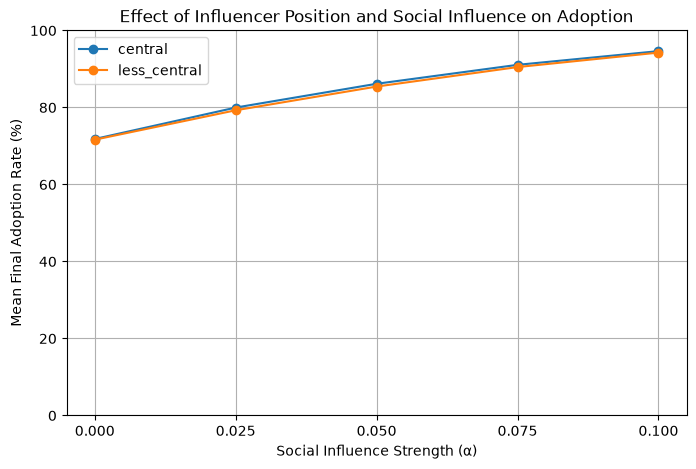

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for strategy in INFLUENCER_STRATEGIES:

    subset = summary[
        summary["strategy"] == strategy
    ]

    plt.plot(
        subset["alpha"],
        subset["mean_adoption_rate"],
        marker="o",
        label=strategy
    )

# Display exact alpha values on X-axis
plt.xticks(
    SOCIAL_INFLUENCE_VALUES,
    [f"{alpha:.3f}" for alpha in SOCIAL_INFLUENCE_VALUES]
)

plt.xlabel("Social Influence Strength (α)")
plt.ylabel("Mean Final Adoption Rate (%)")
plt.title("Effect of Influencer Position and Social Influence on Adoption")

plt.ylim(0, 100)
plt.legend()
plt.grid(True)
plt.show()

### 4.5 Adoption Speed Comparison

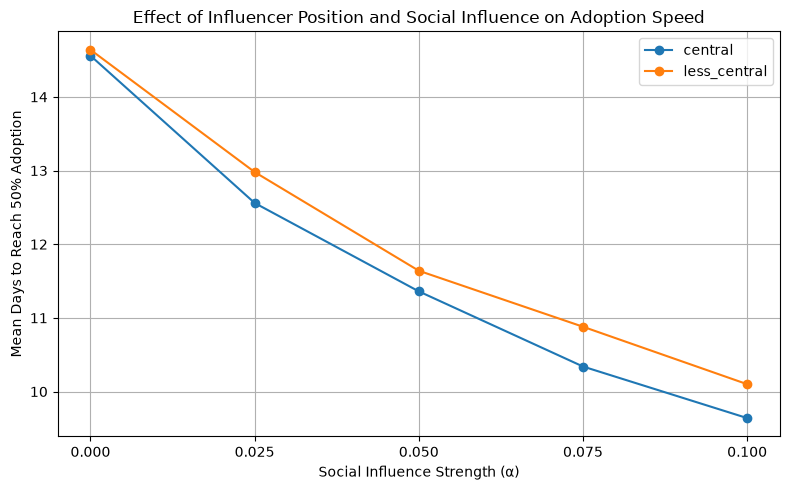

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for strategy in INFLUENCER_STRATEGIES:

    subset = summary[
        summary["strategy"] == strategy
    ]

    plt.plot(
        subset["alpha"],
        subset["mean_adoption_speed"],
        marker="o",
        label=strategy
    )

# Display exact alpha values
plt.xticks(
    SOCIAL_INFLUENCE_VALUES,
    [f"{alpha:.3f}" for alpha in SOCIAL_INFLUENCE_VALUES]
)

plt.xlabel("Social Influence Strength (α)")
plt.ylabel("Mean Days to Reach 50% Adoption")
plt.title("Effect of Influencer Position and Social Influence on Adoption Speed")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 4.6 Paired Comparison of Influencer Positions

In [62]:
from scipy import stats
import numpy as np

paired_results = []

for alpha in SOCIAL_INFLUENCE_VALUES:

    subset = df_results[
        df_results["alpha"] == alpha
    ]

    central = subset[
        subset["strategy"] == "central"
    ].sort_values("run")

    less_central = subset[
        subset["strategy"] == "less_central"
    ].sort_values("run")

    # Difference in final adoption rate
    differences = (
        central["adoption_rate"].to_numpy()
        - less_central["adoption_rate"].to_numpy()
    )

    n = len(differences)

    mean_difference = np.mean(differences)

    standard_error = (
        stats.sem(differences)
    )

    confidence_interval = stats.t.interval(
        confidence=0.95,
        df=n - 1,
        loc=mean_difference,
        scale=standard_error
    )

    paired_results.append({
        "alpha": alpha,
        "mean_difference": mean_difference,
        "ci_lower": confidence_interval[0],
        "ci_upper": confidence_interval[1]
    })

df_paired = pd.DataFrame(paired_results)

print(df_paired.round(3).to_string(index=False))

 alpha  mean_difference  ci_lower  ci_upper
 0.000             0.18    -0.008     0.368
 0.025             0.70     0.359     1.041
 0.050             0.72     0.290     1.150
 0.075             0.58     0.276     0.884
 0.100             0.38     0.151     0.609


### 4.7 Confidence Intervals for Influencer Position

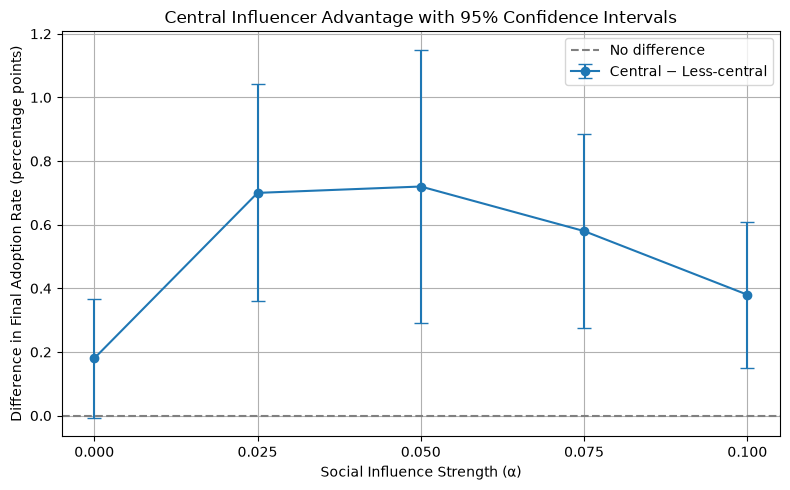

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

lower_error = (
    df_paired["mean_difference"]
    - df_paired["ci_lower"]
)

upper_error = (
    df_paired["ci_upper"]
    - df_paired["mean_difference"]
)

plt.errorbar(
    df_paired["alpha"],
    df_paired["mean_difference"],
    yerr=[lower_error, upper_error],
    fmt="o-",
    capsize=5,
    label="Central − Less-central"
)

# Zero means no difference
plt.axhline(
    y=0,
    color="gray",
    linestyle="--",
    label="No difference"
)

plt.xticks(
    SOCIAL_INFLUENCE_VALUES,
    [f"{alpha:.3f}" for alpha in SOCIAL_INFLUENCE_VALUES]
)

plt.xlabel("Social Influence Strength (α)")
plt.ylabel("Difference in Final Adoption Rate (percentage points)")
plt.title("Central Influencer Advantage with 95% Confidence Intervals")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 4.8 Paired Comparison of Adoption Speed

In [64]:
speed_results = []

for alpha in SOCIAL_INFLUENCE_VALUES:

    subset = df_results[
        df_results["alpha"] == alpha
    ]

    central = subset[
        subset["strategy"] == "central"
    ].sort_values("run")

    less_central = subset[
        subset["strategy"] == "less_central"
    ].sort_values("run")

    # Ensure we compare matching runs
    assert (
        central["run"].to_numpy()
        == less_central["run"].to_numpy()
    ).all()

    # Positive means central is faster
    differences = (
        less_central["adoption_speed"].to_numpy(dtype=float)
        - central["adoption_speed"].to_numpy(dtype=float)
    )

    # Only compare runs where both strategies reached 50%
    differences = differences[~np.isnan(differences)]

    n = len(differences)
    mean_difference = np.mean(differences)

    confidence_interval = stats.t.interval(
        confidence=0.95,
        df=n - 1,
        loc=mean_difference,
        scale=stats.sem(differences)
    )

    speed_results.append({
        "alpha": alpha,
        "paired_runs": n,
        "mean_speed_advantage": mean_difference,
        "ci_lower": confidence_interval[0],
        "ci_upper": confidence_interval[1]
    })

df_speed_paired = pd.DataFrame(speed_results)

print(df_speed_paired.round(3).to_string(index=False))

 alpha  paired_runs  mean_speed_advantage  ci_lower  ci_upper
 0.000           50                  0.08    -0.059     0.219
 0.025           50                  0.42     0.190     0.650
 0.050           50                  0.28     0.057     0.503
 0.075           50                  0.54     0.339     0.741
 0.100           50                  0.46     0.222     0.698


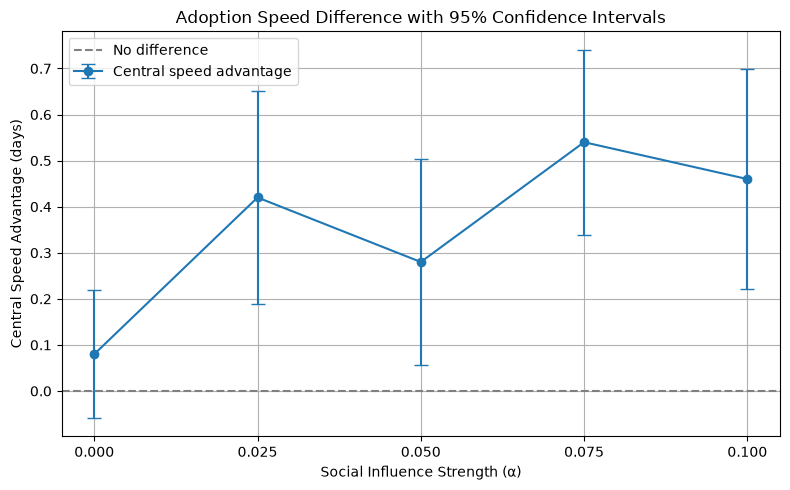

In [65]:
plt.figure(figsize=(8, 5))

lower_error = (
    df_speed_paired["mean_speed_advantage"]
    - df_speed_paired["ci_lower"]
)

upper_error = (
    df_speed_paired["ci_upper"]
    - df_speed_paired["mean_speed_advantage"]
)

plt.errorbar(
    df_speed_paired["alpha"],
    df_speed_paired["mean_speed_advantage"],
    yerr=[lower_error, upper_error],
    fmt="o-",
    capsize=5,
    label="Central speed advantage"
)

plt.axhline(
    0,
    color="gray",
    linestyle="--",
    label="No difference"
)

plt.xticks(
    SOCIAL_INFLUENCE_VALUES,
    [f"{alpha:.3f}" for alpha in SOCIAL_INFLUENCE_VALUES]
)

plt.xlabel("Social Influence Strength (α)")
plt.ylabel("Central Speed Advantage (days)")
plt.title("Adoption Speed Difference with 95% Confidence Intervals")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 4.9 Experiment 1 — Results and Conclusion

#### Results

The experiment investigated the effects of influencer position and social influence strength on fashion product adoption. A total of 500 simulations were conducted across ten experimental conditions, with 50 repetitions per condition.

**Effect of social influence strength**

The results show that increasing social influence strength (α) increased the final adoption rate and reduced the time required to reach 50% adoption for both influencer strategies.

For central influencers, the mean final adoption rate increased from 71.82% at α = 0.000 to 94.64% at α = 0.100. Meanwhile, the mean time to reach 50% adoption decreased from 14.56 to 9.64 days.

Similar patterns were observed for less-central influencers, whose mean final adoption rate increased from 71.64% to 94.26%, while the mean time to 50% adoption decreased from 14.64 to 10.10 days.

**Effect of influencer position**

Central influencers generally produced slightly higher final adoption rates and faster adoption than less-central influencers.

For α values between 0.025 and 0.100, central influencers achieved mean final adoption rates approximately 0.38–0.72 percentage points higher and reached 50% adoption approximately 0.28–0.54 days earlier.

Paired 95% confidence intervals for both outcomes were above zero at these four α values, supporting a small central-influencer advantage within the simulation. At α = 0.000, the confidence intervals included zero, indicating no clear advantage when social influence was disabled.

#### Conclusion

Experiment 1 demonstrates that both influencer position and social influence strength affect fashion product adoption in the simulated consumer network.

Social influence strength had a substantially larger observed effect than influencer position. Increasing α resulted in higher final adoption rates and faster adoption, whereas selecting a central influencer produced comparatively small improvements.

These findings suggest that, within the assumptions of this model, stronger social influence is more important for overall product adoption than whether the initial influencer occupies a central or less-central network position.

However, the results are limited to the selected network structure, purchase-probability assumptions, parameter range, and 28-day simulation period. They should not be interpreted as predictions of real-world consumer purchasing behaviour.

## 5. Experiment 2 — Social Influence Strength




### 5.1 Cumulative Adoption Over Time

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

experiment2_results = []

NUM_RUNS = 50
MAX_STEPS = 28

for alpha in SOCIAL_INFLUENCE_VALUES:

    for run in range(NUM_RUNS):

        G, adoption_history = run_simulation(
            num_customers=100,
            edges_per_new_node=3,
            influencer_strategy="central",
            social_influence=alpha,
            max_steps=MAX_STEPS,
            seed=run
        )

        # Convert adoption counts into percentages
        adoption_rates = [
            adopters / 100 * 100
            for adopters in adoption_history
        ]

        # If everyone adopts early, fill remaining days with 100%
        adoption_rates += [
            adoption_rates[-1]
        ] * (MAX_STEPS + 1 - len(adoption_rates))

        for day, rate in enumerate(adoption_rates):

            experiment2_results.append({
                "alpha": alpha,
                "run": run,
                "day": day,
                "adoption_rate": rate
            })

df_experiment2 = pd.DataFrame(experiment2_results)

print("Total records:", len(df_experiment2))
print(df_experiment2.head())

Total records: 7250
   alpha  run  day  adoption_rate
0    0.0    0    0            1.0
1    0.0    0    1            2.0
2    0.0    0    2           10.0
3    0.0    0    3           17.0
4    0.0    0    4           23.0


In [67]:
daily_summary = (
    df_experiment2
    .groupby(["alpha", "day"])
    .agg(
        mean_adoption=("adoption_rate", "mean"),
        std_adoption=("adoption_rate", "std")
    )
    .reset_index()
)

print(daily_summary.head(10))

   alpha  day  mean_adoption  std_adoption
0    0.0    0           1.00      0.000000
1    0.0    1           2.06      0.998162
2    0.0    2           7.92      2.585991
3    0.0    3          12.52      3.296504
4    0.0    4          16.94      3.672346
5    0.0    5          21.22      3.770400
6    0.0    6          25.26      4.227268
7    0.0    7          29.18      4.470721
8    0.0    8          32.76      4.808835
9    0.0    9          36.38      5.495416


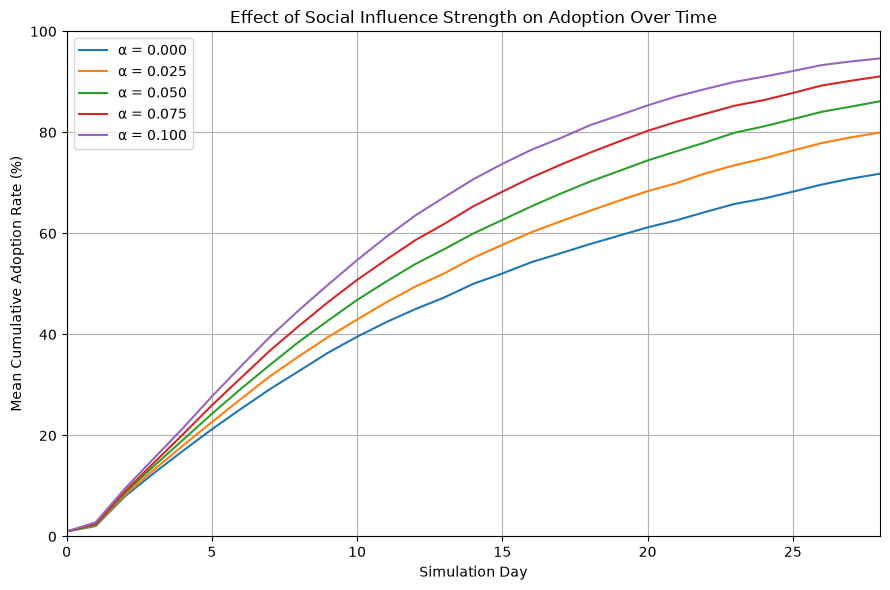

In [68]:
plt.figure(figsize=(9, 6))

for alpha in SOCIAL_INFLUENCE_VALUES:

    subset = daily_summary[
        daily_summary["alpha"] == alpha
    ]

    plt.plot(
        subset["day"],
        subset["mean_adoption"],
        label=f"α = {alpha:.3f}"
    )

plt.xlabel("Simulation Day")
plt.ylabel("Mean Cumulative Adoption Rate (%)")
plt.title("Effect of Social Influence Strength on Adoption Over Time")

plt.xlim(0, 28)
plt.ylim(0, 100)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [69]:
selected_days = [7, 14, 21, 28]

stage_comparison = daily_summary[
    daily_summary["day"].isin(selected_days)
]

comparison_table = stage_comparison.pivot(
    index="alpha",
    columns="day",
    values="mean_adoption"
)

comparison_table.columns = [
    f"Day {day}" for day in comparison_table.columns
]

comparison_table.index = [
    f"{alpha:.3f}" for alpha in comparison_table.index
]

print(comparison_table.round(2).to_string())

       Day 7  Day 14  Day 21  Day 28
0.000  29.18   50.02   62.60   71.82
0.025  31.72   55.16   69.96   79.98
0.050  33.96   59.98   76.26   86.16
0.075  36.80   65.36   82.10   91.08
0.100  39.52   70.72   87.12   94.64


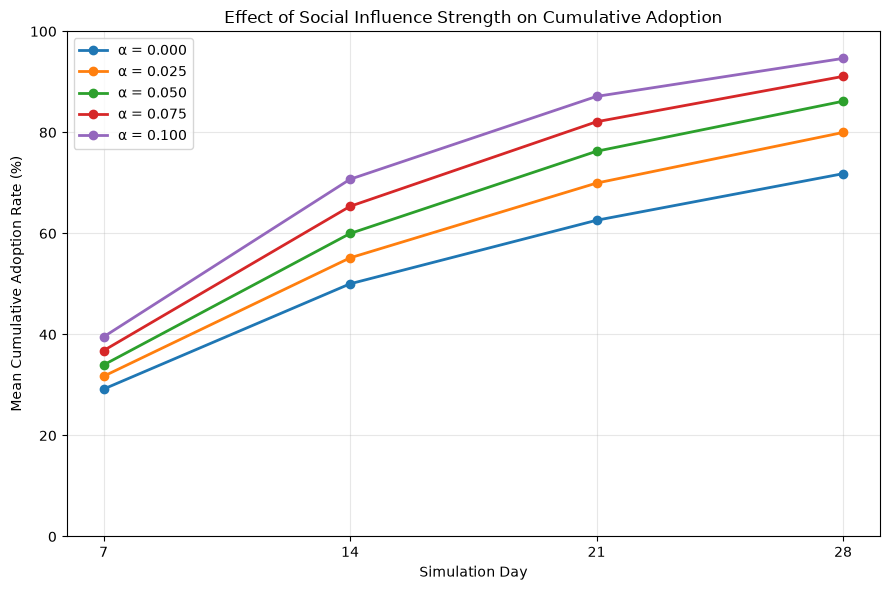

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

for alpha in SOCIAL_INFLUENCE_VALUES:
    subset = daily_summary[
        (daily_summary["alpha"] == alpha) &
        (daily_summary["day"].isin([7, 14, 21, 28]))
    ]

    plt.plot(
        subset["day"],
        subset["mean_adoption"],
        marker="o",
        linewidth=2,
        label=f"α = {alpha:.3f}"
    )

plt.xticks([7, 14, 21, 28])
plt.xlabel("Simulation Day")
plt.ylabel("Mean Cumulative Adoption Rate (%)")
plt.title("Effect of Social Influence Strength on Cumulative Adoption")
plt.ylim(0, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("experiment2_adoption_comparison.png", dpi=300)
plt.show()

### 5.2 Experiment 2 — Results and Conclusion

#### Results

Experiment 2 examined how social influence strength affected cumulative fashion product adoption over a 28-day period. The influencer position was fixed as central, and five social influence strengths (α = 0.000, 0.025, 0.050, 0.075, and 0.100) were compared using 50 simulation runs per condition.

The results show that stronger social influence produced higher cumulative adoption rates throughout the observed stages of the simulation.

On Day 7, mean adoption increased from 29.18% at α = 0.000 to 39.52% at α = 0.100. By Day 14, the corresponding rates were 50.02% and 70.72%. On Day 28, mean final adoption reached 71.82% and 94.64%, respectively.

The difference between the weakest and strongest social influence settings increased from 10.34 percentage points on Day 7 to 24.52 percentage points on Day 21, before decreasing slightly to 22.82 percentage points on Day 28.

These findings indicate that stronger social influence not only increases final adoption but also accelerates the accumulation of purchases during the simulation.

#### Conclusion

Experiment 2 demonstrates that social influence strength affects the timing and extent of product adoption in the simulated consumer network.

Higher α values consistently produced higher mean cumulative adoption at the selected observation days, indicating faster diffusion of the fashion product.

However, adoption also occurred when α = 0.000 because customers retained their individual baseline purchase probabilities. Therefore, social influence was not the sole driver of adoption.

Overall, the experiment suggests that stronger social influence can accelerate fashion product diffusion and increase cumulative adoption within the assumptions of the model.

## 6. Experiment 3 — Influencer Position

### 6.1 Cumulative Adoption Over Time

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

experiment3_results = []

NUM_RUNS = 50
MAX_STEPS = 28
FIXED_ALPHA = 0.050

for strategy in ["central", "less_central"]:

    for run in range(NUM_RUNS):

        G, adoption_history = run_simulation(
            num_customers=100,
            edges_per_new_node=3,
            influencer_strategy=strategy,
            social_influence=FIXED_ALPHA,
            max_steps=MAX_STEPS,
            seed=run
        )

        adoption_rates = [
            adopters / 100 * 100
            for adopters in adoption_history
        ]

        # Extend history to Day 28 if adoption reaches 100% early
        adoption_rates += [
            adoption_rates[-1]
        ] * (MAX_STEPS + 1 - len(adoption_rates))

        for day, rate in enumerate(adoption_rates):

            experiment3_results.append({
                "strategy": strategy,
                "run": run,
                "day": day,
                "adoption_rate": rate
            })

df_experiment3 = pd.DataFrame(experiment3_results)

print("Total records:", len(df_experiment3))
print(df_experiment3.head())

Total records: 2900
  strategy  run  day  adoption_rate
0  central    0    0            1.0
1  central    0    1            2.0
2  central    0    2           10.0
3  central    0    3           17.0
4  central    0    4           24.0


In [72]:
daily_summary3 = (
    df_experiment3
    .groupby(["strategy", "day"])
    .agg(
        mean_adoption=("adoption_rate", "mean"),
        std_adoption=("adoption_rate", "std")
    )
    .reset_index()
)

print(daily_summary3.head(10))

  strategy  day  mean_adoption  std_adoption
0  central    0           1.00      0.000000
1  central    1           2.30      1.129385
2  central    2           8.60      2.634156
3  central    3          13.92      3.509986
4  central    4          19.10      3.829264
5  central    5          24.28      3.875828
6  central    6          29.24      4.605055
7  central    7          33.96      5.014103
8  central    8          38.56      5.429173
9  central    9          42.74      6.087156


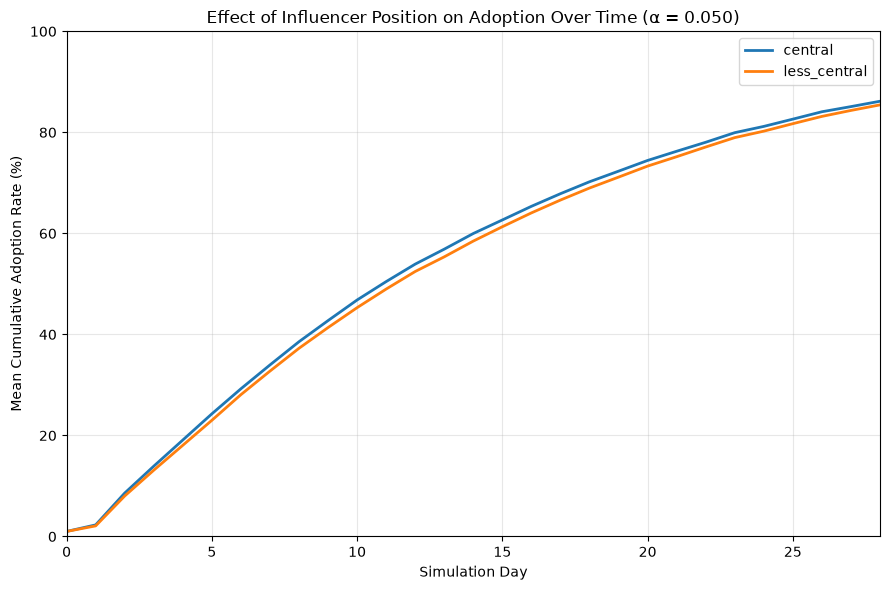

In [73]:
plt.figure(figsize=(9, 6))

for strategy in ["central", "less_central"]:

    subset = daily_summary3[
        daily_summary3["strategy"] == strategy
    ]

    plt.plot(
        subset["day"],
        subset["mean_adoption"],
        linewidth=2,
        label=strategy
    )

plt.xlabel("Simulation Day")
plt.ylabel("Mean Cumulative Adoption Rate (%)")
plt.title("Effect of Influencer Position on Adoption Over Time (α = 0.050)")

plt.xlim(0, 28)
plt.ylim(0, 100)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [74]:
selected_days = [7, 14, 21, 28]

stage_comparison3 = daily_summary3[
    daily_summary3["day"].isin(selected_days)
]

comparison_table3 = stage_comparison3.pivot(
    index="strategy",
    columns="day",
    values="mean_adoption"
)

comparison_table3.columns = [
    f"Day {day}" for day in comparison_table3.columns
]

print(comparison_table3.round(2).to_string())

              Day 7  Day 14  Day 21  Day 28
strategy                                   
central       33.96   59.98   76.26   86.16
less_central  32.74   58.48   75.18   85.44


In [75]:
daily_comparison = daily_summary3.pivot(
    index="day",
    columns="strategy",
    values="mean_adoption"
)

daily_comparison["difference"] = (
    daily_comparison["central"]
    - daily_comparison["less_central"]
)

max_day = daily_comparison["difference"].idxmax()
max_difference = daily_comparison["difference"].max()

print("Day with largest difference:", max_day)
print(f"Largest difference: {max_difference:.2f} percentage points")

Day with largest difference: 10
Largest difference: 1.52 percentage points


### 6.2 Experiment 3 — Results and Conclusion

#### Results

Experiment 3 compared central and less-central influencers over 28 days, with α = 0.050 and 50 simulations per strategy.

Central influencers achieved slightly higher adoption rates throughout the selected observation days. The largest observed mean difference occurred on **Day 10 (1.52 percentage points)**. This advantage decreased to **0.72 percentage points by Day 28**, with final adoption rates of 86.16% for central influencers and 85.44% for less-central influencers.

#### Conclusion

The results suggest that central influencers provide a small advantage in early product adoption, but the difference becomes smaller over time. Overall, **social influence strength has a greater effect on product adoption than influencer position** within the simulated network.

## 7. Model Validation and Testing

This section verifies that the simulation follows its intended rules, including reproducibility, irreversible adoption, valid purchase probabilities, and correct initial conditions.

### Test 1 — Reproducibility
Running the simulation twice with identical parameters and the same random seed should produce identical results.

In [76]:
G1, history1 = run_simulation(
    num_customers=100,
    edges_per_new_node=3,
    influencer_strategy="central",
    social_influence=0.05,
    max_steps=28,
    seed=42
)

G2, history2 = run_simulation(
    num_customers=100,
    edges_per_new_node=3,
    influencer_strategy="central",
    social_influence=0.05,
    max_steps=28,
    seed=42
)

assert history1 == history2

print("Test 1 PASSED: Results are reproducible.")

Test 1 PASSED: Results are reproducible.


### Test 2 — Adoption never decreases
Once a consumer purchases the product, they cannot become unpurchased.

In [77]:
assert all(
    history1[i + 1] >= history1[i]
    for i in range(len(history1) - 1)
)

print("Test 2 PASSED: Adoption never decreases.")

Test 2 PASSED: Adoption never decreases.


### Test 3 — Purchase probabilities are valid
Every purchase probability must remain between 0 and 1.

In [78]:
for customer in G1.nodes():

    probability = purchase_probability(
        G1,
        customer,
        social_influence=0.05
    )

    assert 0 <= probability <= 1

print("Test 3 PASSED: All probabilities are valid.")

Test 3 PASSED: All probabilities are valid.


### Test 4 — Correct initial conditions
The simulation must start with exactly one adopter.

In [79]:
assert history1[0] == 1

print("Test 4 PASSED: Simulation starts with one adopter.")

Test 4 PASSED: Simulation starts with one adopter.


### Test 5 — Adoption never exceeds the population
The number of adopters cannot exceed 100 consumers.

In [80]:
assert all(
    0 <= adopters <= 100
    for adopters in history1
)

print("Test 5 PASSED: Adoption stays within population limits.")

Test 5 PASSED: Adoption stays within population limits.


### 7.1 Validation Results

Five tests were conducted to verify the simulation's basic correctness.

| Test | Expected Behaviour | Result |
|---|---|---|
| Reproducibility | Identical seeds produce identical adoption histories | Passed |
| Irreversible adoption | Total adoption never decreases | Passed |
| Purchase probability | Probabilities remain between 0 and 1 | Passed |
| Initial conditions | Simulation starts with one adopter | Passed |
| Population limits | Total adopters never exceed 100 | Passed |

All five tests passed, confirming that the tested simulation follows its intended rules.

However, these tests verify selected aspects of model implementation rather than its ability to predict real-world consumer behaviour.

## 8. Project Summary and Conclusion

This project developed an agent-based simulation to investigate how influencer position and social influence strength affect fashion product adoption within a consumer social network.

Three experiments examined final adoption rates, adoption speed, and cumulative adoption patterns over 28 days.

The results indicate that **both influencer position and social influence strength affect product adoption**. Stronger social influence substantially increased adoption rates and accelerated product diffusion, while central influencers provided a smaller advantage, particularly during earlier stages.

Overall, **social influence strength was the dominant factor affecting adoption within the simulated network**, whereas influencer position had a relatively limited effect.

However, these findings depend on the model's assumptions and parameter settings and should not be interpreted as direct predictions of real-world consumer behaviour.